## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load training data source into a dataframe & perform basic data checks

In [2]:
df = pd.read_csv("data/raw/train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


#### 2.1 Shape of dataset

In [3]:
print(f"No. of rows: {df.shape[0]}")
print(f"No. of columns: {df.shape[1]}")

No. of rows: 439140
No. of columns: 16


#### 2.2 Schema of dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

#### 2.3 Check for Null values

In [5]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

#### 2.4 Check for duplicate rows

In [6]:
print(f"No of duplicate rows: {df.duplicated().sum()}")

No of duplicate rows: 0


In [7]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


# 3. Class imbalance check

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


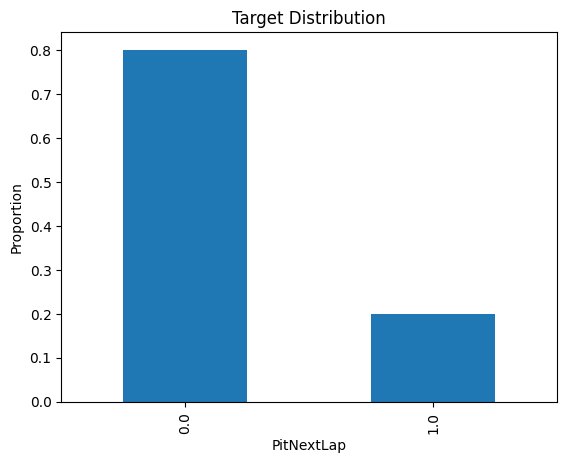

In [8]:
balance = df['PitNextLap'].value_counts(normalize=True)
print(balance)

# Visualize it
balance.plot(kind='bar', title='Target Distribution')
plt.ylabel('Proportion')
plt.show()

# 4. Identifying Numerical & Nominal attributes

Since some columns are nominal in nature but are forced to be numerical due to their datatypes, therefore appending those columns to this list before plotting

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [42]:
categorial_cols = []
numerical_cols = []

all_columns = df.columns.to_list()
for cols in all_columns:

    # check for object, category and bool datatype
    if (df[cols].nunique() <= 10) or (df[cols].dtype) =="str":
        categorial_cols.append(cols)
    
    # left over true numerical cols
    else:
        numerical_cols.append(cols)

print(categorial_cols)
print(numerical_cols)

['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'PitNextLap']
['id', 'LapNumber', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


In [41]:
df['LapNumber'].nunique()

78

# 5. Univariate Analysis

#### 5.1 Plot the count distribution of categorical columns having less than 10 unique values

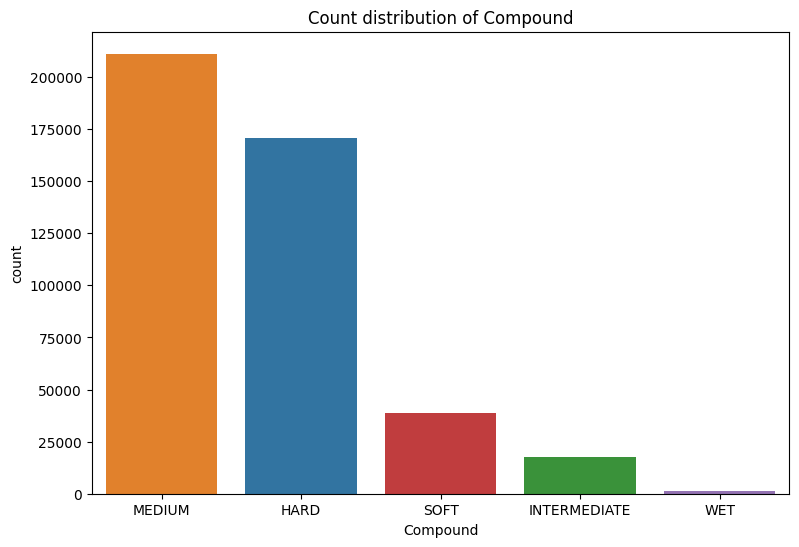

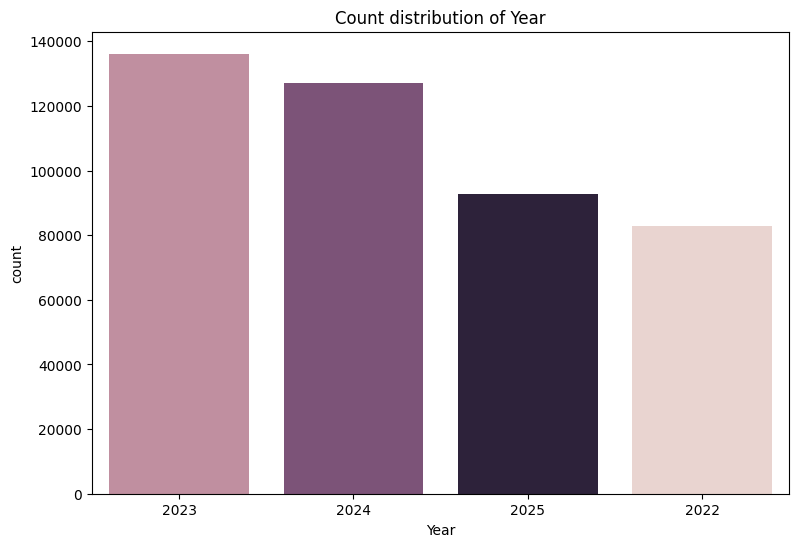

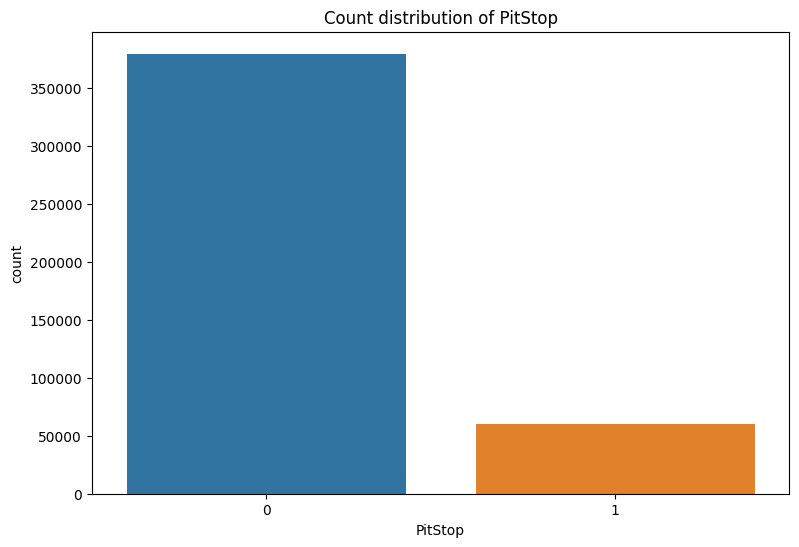

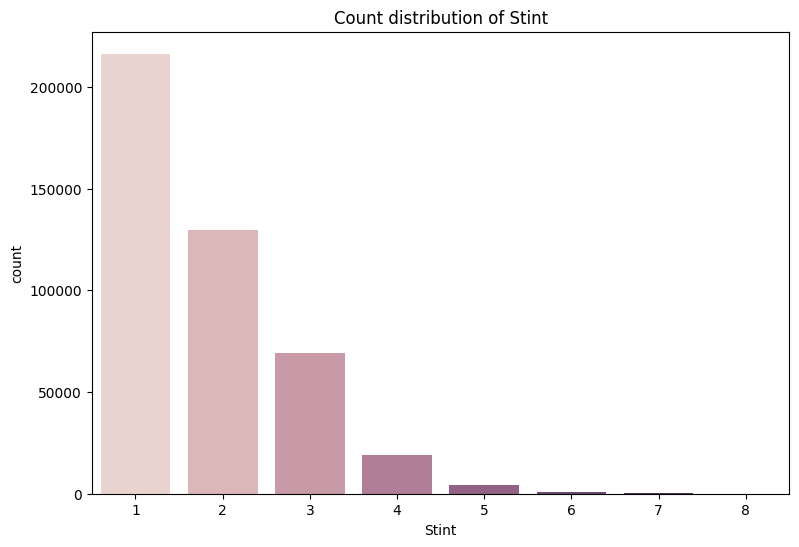

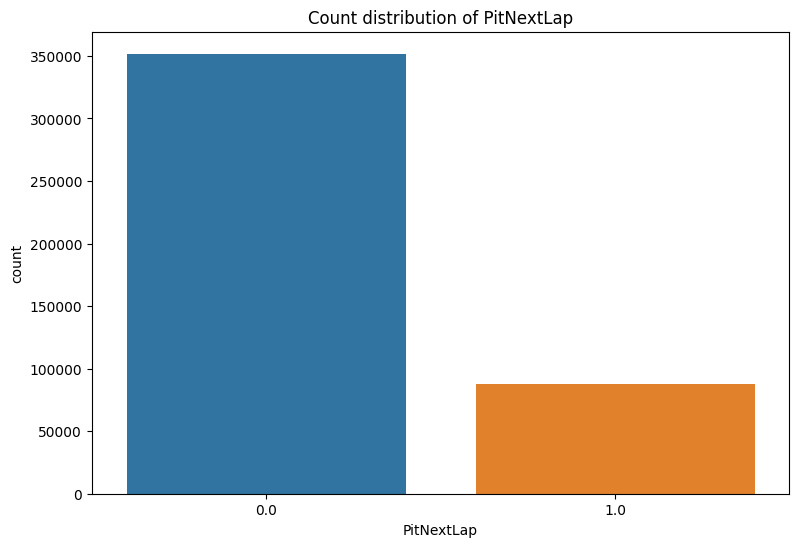

In [43]:
for cols in categorial_cols:
    if (df[cols].nunique() <= 10):
        order = df[cols].value_counts().sort_values(ascending=False).index
        plt.figure(figsize=(9,6))
        plt.title(f"Count distribution of {cols}")
        sb.countplot(data=df, x = cols, hue = cols, order = order, legend=False)
        plt.show()

#### 5.2 Plot the count and density distribution of numerical columns

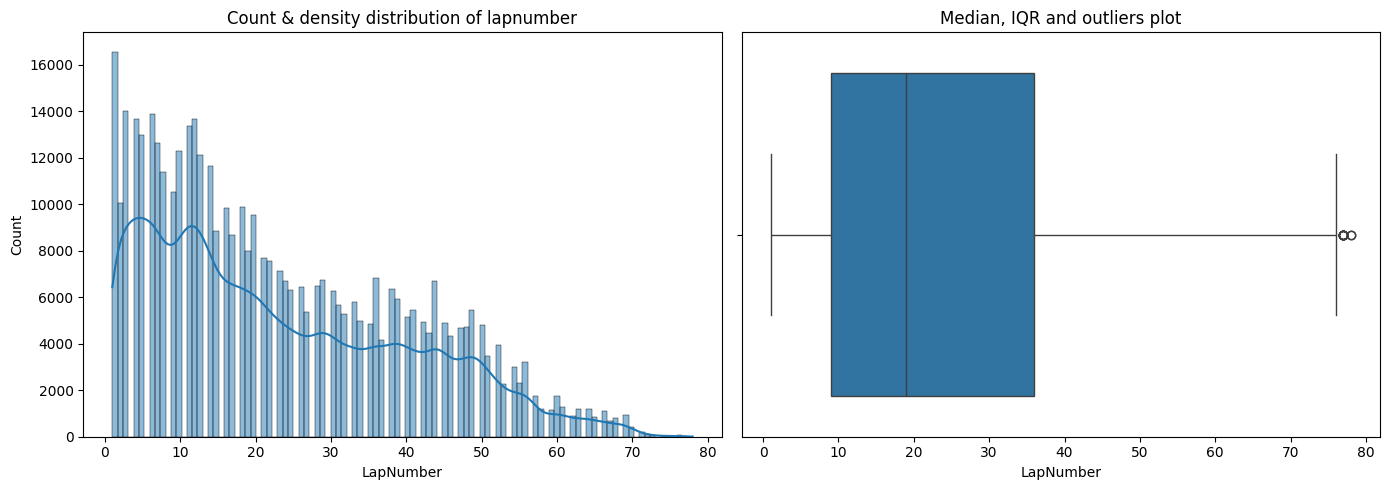

In [49]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="LapNumber",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of lapnumber")

# second plot
sb.boxplot(data=df, x='LapNumber', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

The following results can be concluded from the above graph:
1. Majority of the data points belong to early Lap ranges (1-20)
2. The distribution plot signifies the data set is right skewed as the tail strecthes towards higher lap numbers

Since the median is shifted towards the left inside the Boxplot, it confirms the dataset is right skewed
There are only two dots beyond whiskeres, indicating outliers towards high lap numbers
IQR = Q3 - Q1 = 35 - 10 = 25
Lower Bound = 10 - 1.5×25 = -27.5 → effectively 0 (no lower outliers)
Upper Bound = 35 + 1.5×25 = 72.5 → anything above ~72 is an outlier

Observations:

LapNumber ranges from approximately 2 to 80
Median is around Lap 20, meaning more than half the pit-related events occur in the first half of the race
Q1 ≈ 10, Q3 ≈ 35 → 50% of all data sits between Lap 10 and Lap 35
The box is shifted towards the left, confirming right skew (consistent with KDE finding)
Two outlier points exist near Lap 77-80 — very late race laps are rare in this dataset

In [50]:
numerical_cols

['id',
 'LapNumber',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change']

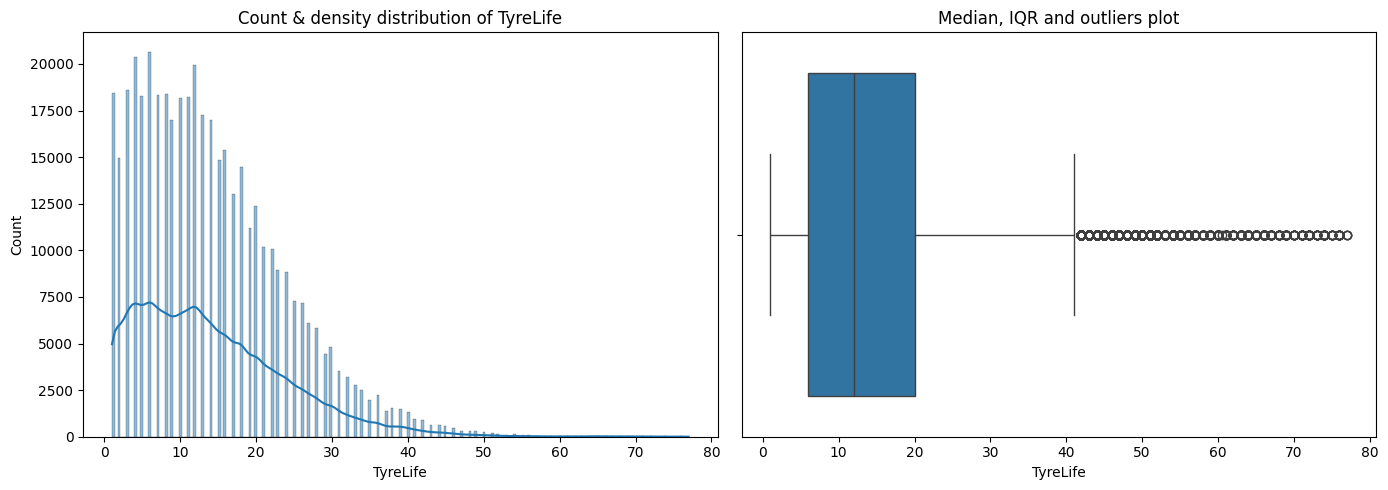

In [51]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="TyreLife",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of TyreLife")

# second plot
sb.boxplot(data=df, x='TyreLife', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

IQR = Q3 - Q1 = 20 - 8 = 12
Lower Bound = 8 - 1.5×12 = -10 → effectively 0 (no lower outliers)
Upper Bound = 20 + 1.5×12 = 38 → anything above ~38-42 is an outlier

TyreLife ranges from 0 to ~78 laps but majority of data is concentrated in 0–40 range
Median tyre age is approximately Lap 13, meaning half the pit/race observations happen before tyre completes 13 laps
Q1 ≈ 8, Q3 ≈ 20 → 50% of all tyre usage falls between Lap 8 and Lap 20
Distribution is heavily right-skewed — most tyres are used for fewer laps, very few tyres run extremely long
Bimodal KDE with two peaks at ~5 and ~11 suggests two distinct tyre usage patterns in the dataset
Large number of outliers on the right side (Lap 43–78) — these represent unusually long tyre stints

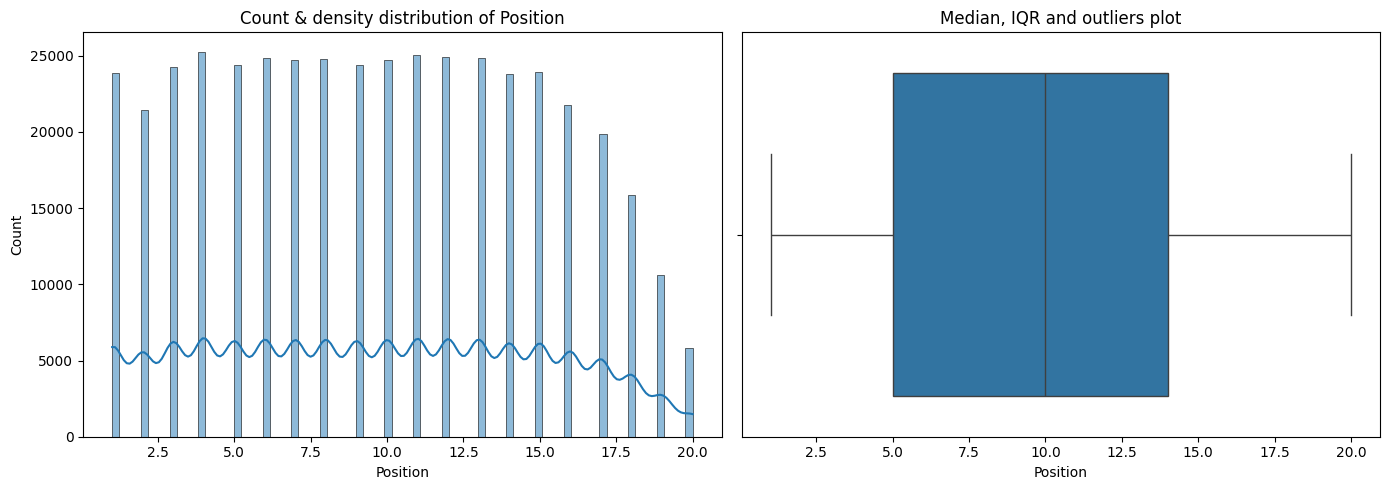

In [52]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="Position",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of Position")

# second plot
sb.boxplot(data=df, x='Position', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()

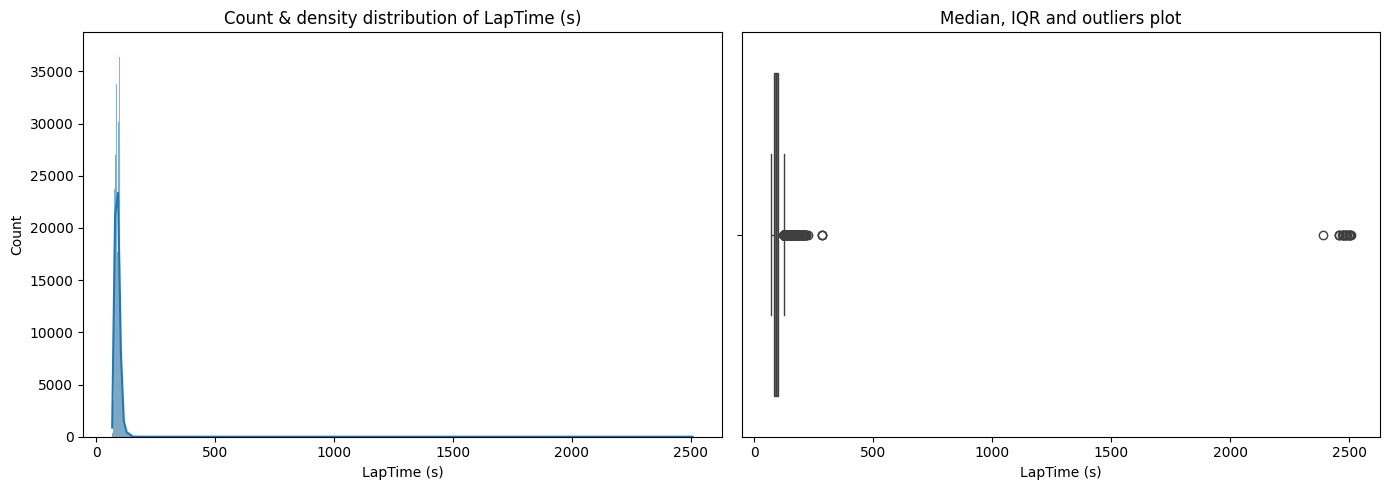

In [53]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sb.histplot(data=df,x="LapTime (s)",kde=True,ax = axes[0])
axes[0].set_title("Count & density distribution of LapTime (s)")

# second plot
sb.boxplot(data=df, x='LapTime (s)', ax=axes[1])
axes[1].set_title("Median, IQR and outliers plot")

plt.tight_layout()
plt.show()